Accuracy: 0.9712


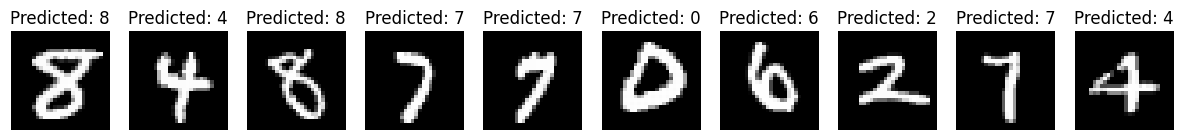

In [1]:
#image classification with the help of ann on mnist dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Create and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)
# Evaluate the model
accuracy = mlp.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy:.4f}')
# Predict on the test set
y_pred = mlp.predict(X_test_scaled)
# Visualize some predictions
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(X_test.iloc[i].values.reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Predicted: {y_pred[i]}')
    axes[i].axis('off')
plt.show()

In [1]:
import numpy as np


class SimpleANN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = learning_rate

        # Xavier initialization
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1. / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1. / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-12, 1.0)   # avoid log(0)
        log_likelihood = -np.log(y_pred[np.arange(m), y_true])
        return np.mean(log_likelihood)

    def backward(self, X, y_true):
        m = X.shape[0]

        # Copy output so original self.a2 is not modified
        delta2 = self.a2.copy()
        delta2[np.arange(m), y_true] -= 1
        delta2 /= m

        dW2 = np.dot(self.a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)

        delta1 = np.dot(delta2, self.W2.T) * self.sigmoid_derivative(self.a1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # Update parameters
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=100):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.backward(X, y)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)


# Example usage
if __name__ == "__main__":
    from sklearn.datasets import fetch_openml
    from sklearn.model_selection import train_test_split

    # Load MNIST
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X, y = mnist.data, mnist.target.astype(int)

    # Normalize
    X = X / 255.0

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Create model
    input_size = X_train.shape[1]   # 784
    hidden_size = 100
    output_size = 10

    ann = SimpleANN(input_size, hidden_size, output_size, learning_rate=0.1)

    # Train
    ann.train(X_train, y_train, epochs=100)

    # Test
    predictions = ann.predict(X_test)
    accuracy = np.mean(predictions == y_test)

    print(f"Accuracy: {accuracy:.4f}")

Epoch 10/100, Loss: 2.2341
Epoch 20/100, Loss: 2.1639
Epoch 30/100, Loss: 2.0947
Epoch 40/100, Loss: 2.0243
Epoch 50/100, Loss: 1.9517
Epoch 60/100, Loss: 1.8770
Epoch 70/100, Loss: 1.8006
Epoch 80/100, Loss: 1.7232
Epoch 90/100, Loss: 1.6460
Epoch 100/100, Loss: 1.5702
Accuracy: 0.7428
